# Rockall Trough glider section - EOF analysis

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append(r'../') # Add this line at the beginner of each notebook to be able to load local functions 
import src.features.RT_functions as rtf
import src.features.RT_data as rtd
import src.features.matfile_functions as matlab_fct
import src.features.RT_transport as rtt
import src.features.RT_EOF_functions as rt_eof
import src.set_paths as sps
import src.RT_parameters as rtp
import src.features.RT_visualise as rtv

C:\Users\sa07kb\Projects\Rockall_Trough_Transports\notebooks\..\src\features\RT_transport.py:9: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
import dask
import datetime
import gsw
import numpy as np
import pandas as pd
import mat73
import xarray as xr
from pathlib import Path
import xeofs as xe
from eofs.xarray import Eof

from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')
xr.set_options(display_expand_attrs=False)
%matplotlib inline

# Set in- and output path

In [3]:
date_str_start = '2020'
date_str_end = '2025'
fn_version = 'v0'
script_name = f"2.3_compare_eof_tools"

# output figures
fig_out_path = (sps.local_fig_dir/f"{script_name}")
Path(fig_out_path).mkdir(parents=True, exist_ok=True)

In [4]:
# mooring intput data
fn_in_version = 'v1'
fn_base_grid = "Rockall_Trough_mooring_gridded_TSUV"
fn_base_stack = "Rockall_Trough_mooring_stacked_TSUV"
date_str_start_moor = '201407'
date_str_end_moor = '202407'

RT_mooring_fn = f"{fn_base_grid}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"
file_name_in_stack = f"{fn_base_stack}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"

# transport input data
fn_in_version = 'v0'
fn_base_grid = "Rockall_Trough_transport_3D_TIME_series"
RT_transp_grid_fn = f"{fn_base_grid}_{date_str_start_moor}_{date_str_end_moor}_{fn_in_version}.nc"

prep_RT_mooring_data_path = (sps.local_data_dir/f'0.0_Rockall_Trough_moorings_data_prep_{date_str_start_moor}_{date_str_end_moor}_v0/')
RT_transport_data_path_v0 = (sps.local_data_dir/f'1.0_Rockall_Trough_transports_{date_str_start_moor[:-2]}_{date_str_end_moor[:-2]}_v0/')
RT_transport_data_path_v1 = (sps.local_data_dir/f'3.0_Rockall_Trough_transports_{date_str_start_moor[:-2]}_{date_str_end_moor[:-2]}_v1/')

# Load data

In [5]:
# Rockall Trough mooring location
ds_RT_loc=rtd.load_RT_loc()

# load gridded Rockall Trough mooring data
ds_RT = rtd.load_RT_moor(RT_mooring_fn)

# Extrapolate top and linearly interpolate over gaps
ds_RT = rtf.prep_mooring_data_for_transport_calc(ds_RT,ds_RT_loc)

# Get dz (top/bottom cells are ~10m thick, cells are ~20m thick elsewhere)
dz = rtt.get_dz(ds_RT.depth)
ds_RT['dz']=xr.DataArray(dz,dims='depth')

Load existing data set.


In [6]:
#load glider
ds_glider_mat = matlab_fct.load_glider_mat(sps.glider_data_path,sps.glider_fn)
ds_glider_mat_nan = rt_eof.add_nan_glider_sections(ds_glider_mat,dim='time')

In [7]:
ds_glider = ds_glider_mat
ds_glider_nan = ds_glider_mat_nan

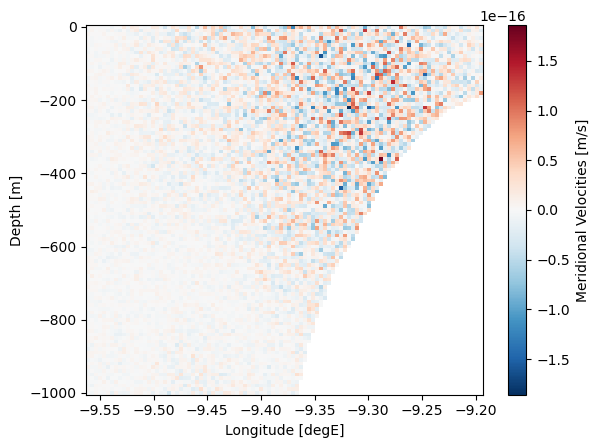

In [8]:
test_vcur = ds_glider.vcur 
test_mean = test_vcur.mean('time')
test_vcur = test_vcur-test_mean
test_vcur.mean('time').plot(x='lon')

# EOF analysis using xeof

In [9]:
model = xe.single.EOF(n_modes=5, 
                      standardize=False,use_coslat=False,check_nans=True)
model.fit(test_vcur, dim="time")
expvar = model.explained_variance_ratio()
components = model.components()
scores = model.scores()

In [10]:
n_boot = 50

bs = xe.validation.EOFBootstrapper(n_bootstraps=n_boot)
bs.fit(model)
bs_expvar = bs.explained_variance()
ci_expvar = bs_expvar.quantile([0.025, 0.975], "n")  # 95% confidence intervals

q025 = ci_expvar.sel(quantile=0.025)
q975 = ci_expvar.sel(quantile=0.975)

is_significant = q025 - q975.shift({"mode": -1}) > 0
n_significant_modes = (
    is_significant.where(is_significant is True).cumsum(skipna=False).max().fillna(0)
)
print("{:} modes are significant at alpha=0.05".format(n_significant_modes.values))

100%|██████████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  5.98it/s]


0.0 modes are significant at alpha=0.05


In [11]:
ci_components = bs.components().quantile([0.025, 0.975], "n")
ci_scores = bs.scores().quantile([0.025, 0.975], "n")

is_sig_comps = np.sign(ci_components).prod("quantile") > 0

In [12]:
print(model.explained_variance().values)

[86.78851931 16.80950708 12.02248841  9.71665737  8.17050502]


In [13]:
print(model.explained_variance_ratio().values)

[0.54187544 0.10495235 0.07506397 0.06066722 0.05101361]


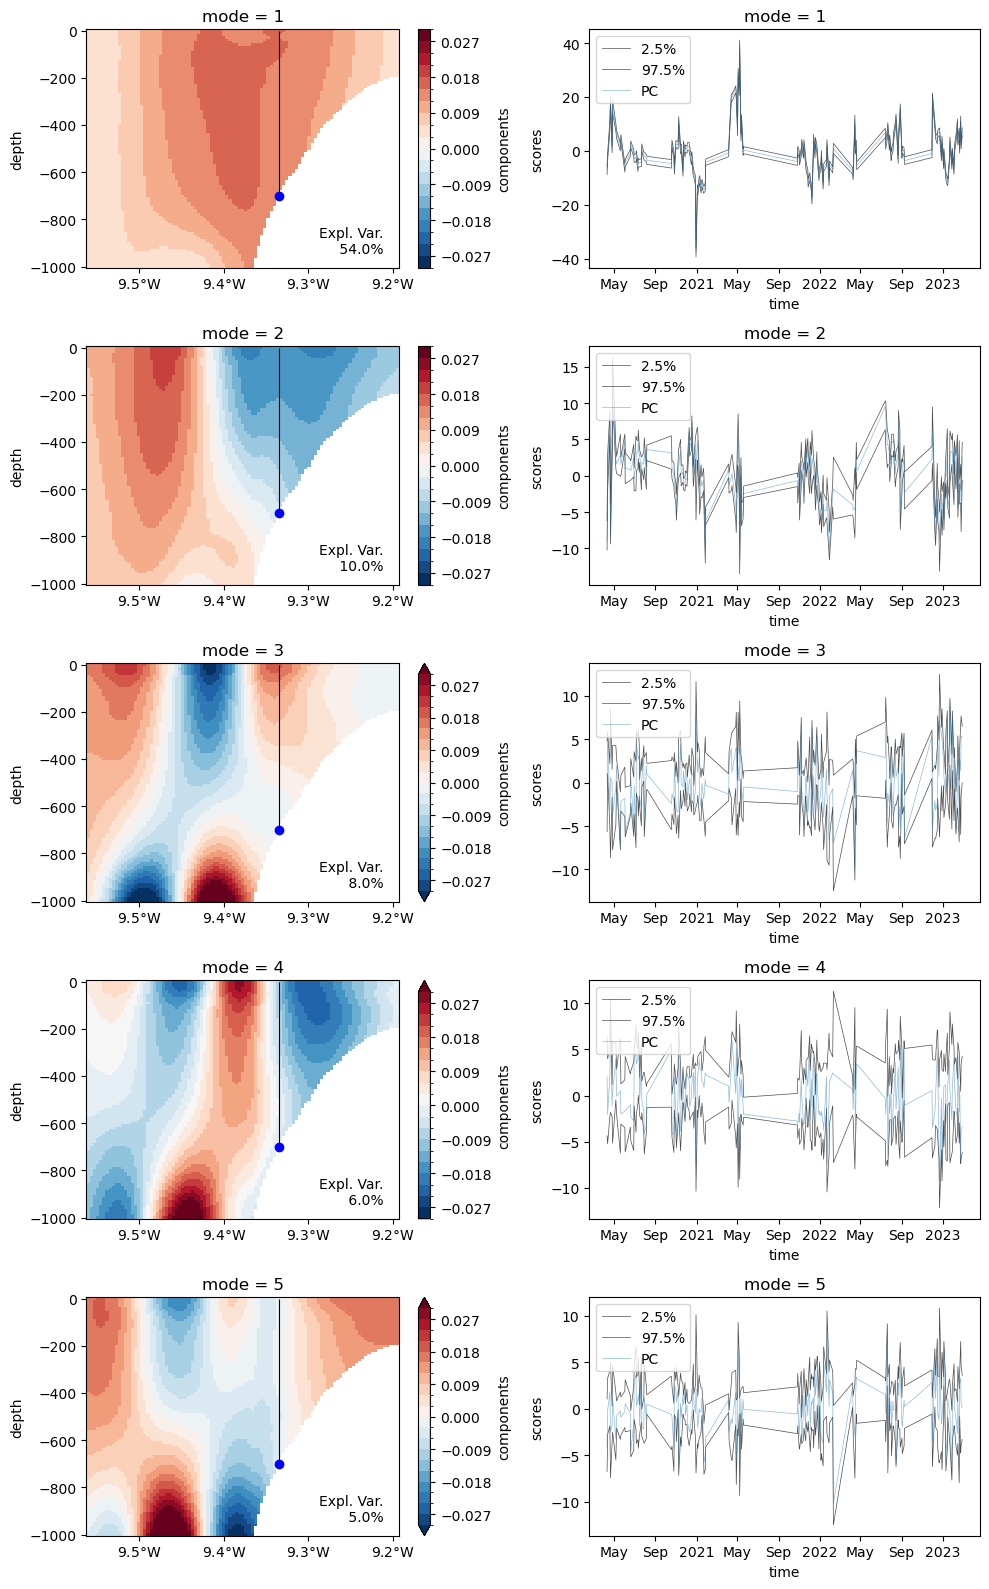

In [14]:
kwargs = {"cmap": "RdBu_r", "vmin": -0.03, "vmax": 0.03,"levels":21}
lons, z = np.meshgrid(is_sig_comps.lon.values, is_sig_comps.depth.values)

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 16))
gs = GridSpec(5, 2)
ax1 = [fig.add_subplot(gs[i, 0]) for i in range(5)]
ax2 = [fig.add_subplot(gs[i, 1]) for i in range(5)]



for i, (a1, a2) in enumerate(zip(ax1, ax2)):
    components.isel(mode=i).plot(ax=a1,x='lon', **kwargs)
    # a1.scatter(
    #     lons,
    #     z,
    #     is_sig_comps.isel(mode=i).values * 0.5,
    #     color="k",
    #     alpha=0.5,
    # )
    a1.vlines(ds_RT_loc.lon_RTADCP,-700,0,color='k',lw=.8)
    a1.plot(ds_RT_loc.lon_RTADCP,-700,'ob')
        
    # Apply the custom formatter to the x-axis
    rtv.axis_lat_lon_formatter(a1,'xlon')
    
    a1.text(0.95, 0.05,f'Expl. Var.\n {(expvar * 100).round(0).values[i]:02.1f}%',
                    transform=a1.transAxes, 
                     verticalalignment='bottom',horizontalalignment='right')
    ci_scores.isel(mode=i, quantile=0).plot(ax=a2, color=".3", lw=".5", label="2.5%")
    ci_scores.isel(mode=i, quantile=1).plot(ax=a2, color=".3", lw=".5", label="97.5%")
    scores.isel(mode=i).plot(ax=a2, lw=".5", alpha=0.5, label="PC")
    a2.legend(loc=2)

plt.tight_layout()
plt.savefig(fig_out_path/"xeof_analysis_with_bootstrap.jpg")

### using rt_eof function which uses xeofs

In [15]:
# recreate using EOFs and scores
v_rec_EOF = -1*model.components()*model.scores()
v_rec_EOF['x']=test_vcur.x
v_rec_EOF['lat']=test_vcur.lat

In [16]:
ds_glider['Q']=(rt_eof.calc_transport(test_vcur+test_mean))
ds_glider['Q_rec_EOF']=rt_eof.calc_transport(v_rec_EOF.cumsum('mode')-test_mean)
ds_glider['Q_A']=(rt_eof.calc_transport(test_vcur))
ds_glider['Q_rec_EOF_single']=rt_eof.calc_transport(v_rec_EOF)

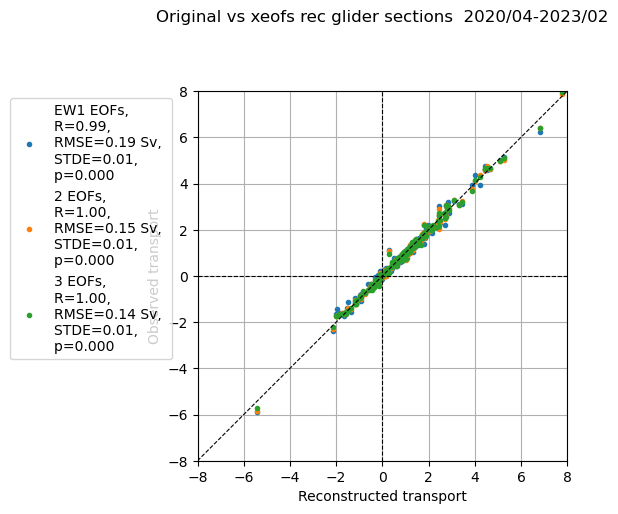

In [17]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q,
                  ds_glider.Q_rec_EOF,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Original vs xeofs rec glider sections  {rtv.date_str_func(ds_glider,dim='time')}', pad=50)

plt.savefig(fig_out_path/"xeof_Q_rec_using_eofs_vs_observed.jpg")

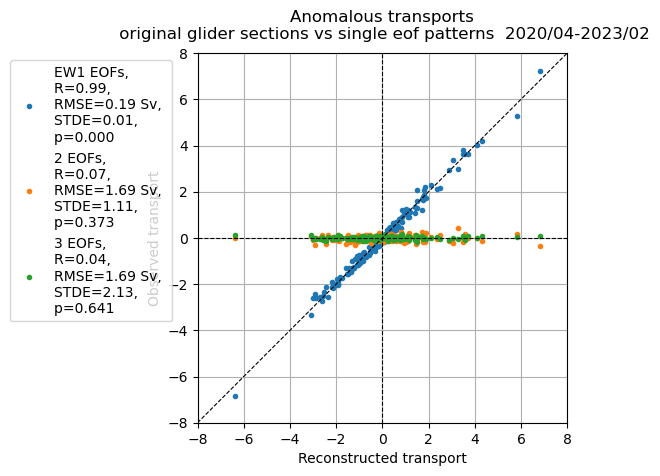

In [18]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q_A,
                  ds_glider.Q_rec_EOF_single,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Anomalous transports\n original glider sections vs single eof patterns  {rtv.date_str_func(ds_glider,dim='time')}', pad=10)

plt.savefig(fig_out_path/"xeof_Q_rec_using_single_eofs_vs_observed.jpg", bbox_inches='tight')

# Perform eof now using eofs

In [19]:
# time needs to be first dimension
test_vcur = test_vcur.transpose('time', 'lon', 'depth')

In [20]:
# Create an EOF solver to do the EOF analysis. 
solver = Eof(test_vcur,center=False)

# Retrieve the nmodes leading EOF, expressed as the covariance between the leading PC
# time series and the input anomalies at each grid point.
nmodes = 5
eof1_co = solver.eofsAsCovariance(neofs=nmodes)

# Retreive nmodes leading EOFs scaled by the square-root of their eigenvalues
# (eofscaling = 0, un-scaled is default), 
eof1 = solver.eofs(neofs=nmodes, eofscaling=0)

# Retreive nmodes leading PCs (default)
pc1 = solver.pcs(npcs=nmodes, pcscaling=0)

# The fractional variance represented by the first nmodes eigenvalues:
variance_fractions = solver.varianceFraction(neigs=nmodes)
print(variance_fractions)
# Reconstructed data field based on a subset of EOFs.
# Reconstruct the input field using nmodes EOFs:

for i in range(nmodes):
    if i==0:
        reconstruction = solver.reconstructedField(i+1)
    else:
        reconstruction = xr.concat([reconstruction,
                                    solver.reconstructedField(i+1)],
                                   dim='mode')

<xarray.DataArray 'variance_fractions' (mode: 5)> Size: 40B
array([0.54187544, 0.10495235, 0.07506397, 0.06066722, 0.05101361])
Coordinates:
  * mode     (mode) int64 40B 0 1 2 3 4
Attributes: (1)


In [21]:
solver.eigenvalues(neigs=nmodes)

<xarray.DataArray 'eigenvalues' (mode: 5)> Size: 40B
array([86.78851931, 16.80950708, 12.02248841,  9.71665737,  8.17050502])
Coordinates:
  * mode     (mode) int64 40B 0 1 2 3 4
Attributes: (1)

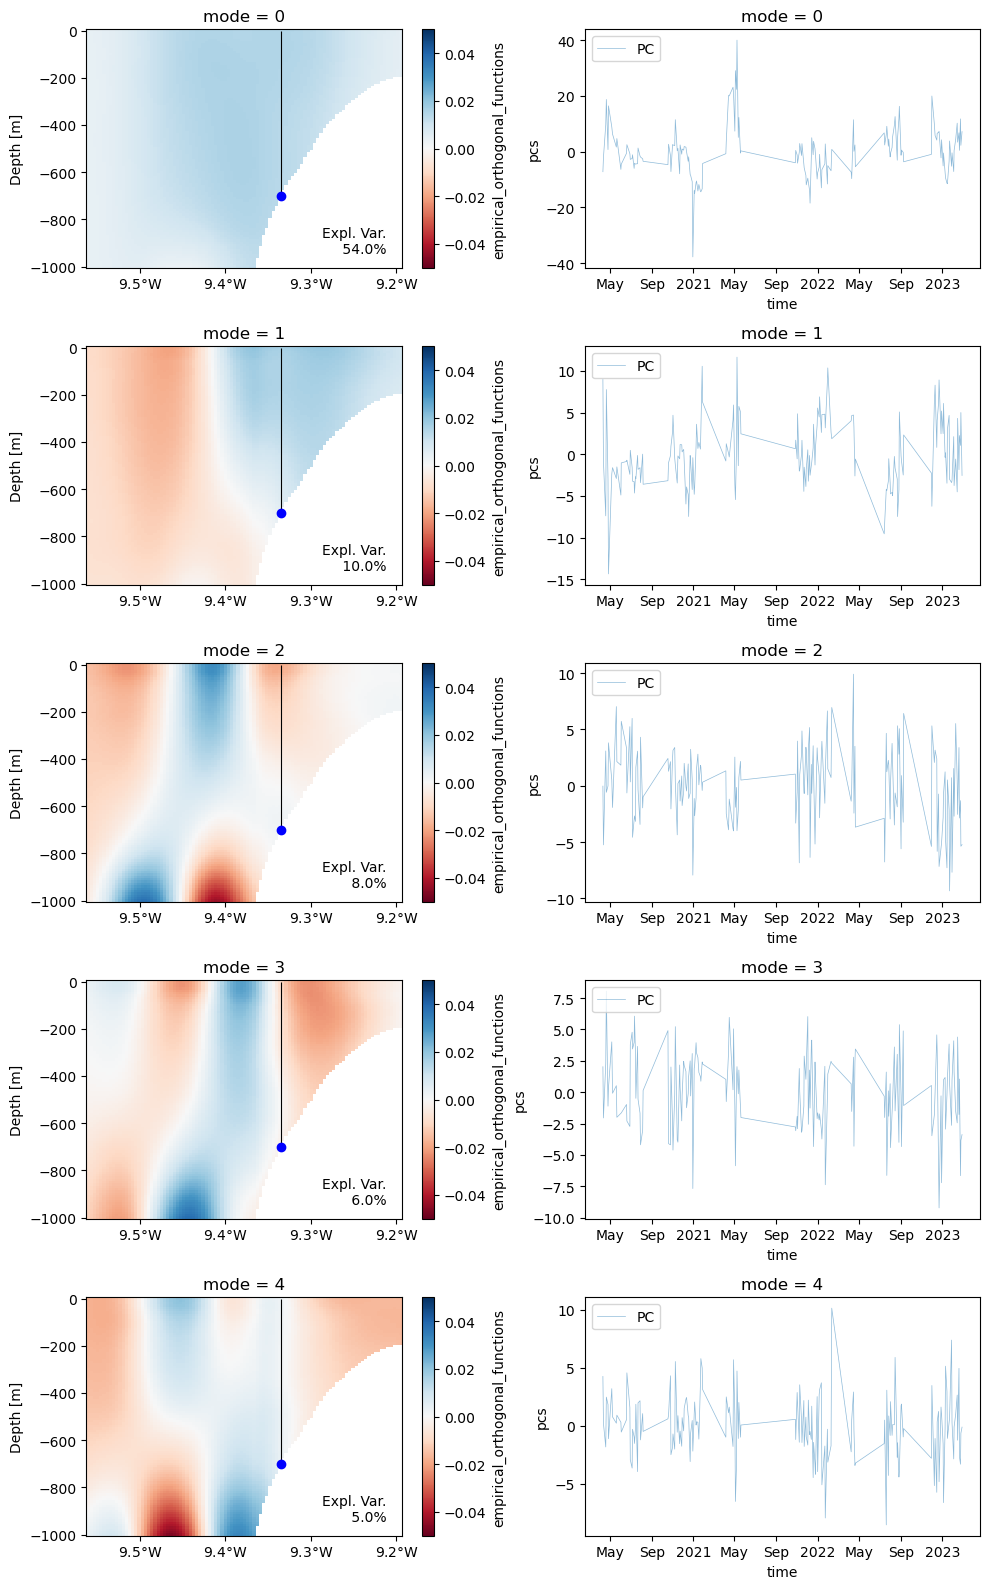

In [22]:
kwargs = {"cmap": "RdBu", "vmin": -0.05, "vmax": 0.05}

fig = plt.figure(figsize=(10, 16))
gs = GridSpec(5, 2)
ax1 = [fig.add_subplot(gs[i, 0]) for i in range(5)]
ax2 = [fig.add_subplot(gs[i, 1]) for i in range(5)]

for i, (a1, a2) in enumerate(zip(ax1, ax2)):
    eof1.isel(mode=i).plot(ax=a1,x='lon', **kwargs)
    a1.text(0.95, 0.05,f'Expl. Var.\n {(variance_fractions * 100).round(0).values[i]:02.1f}%',
                    transform=a1.transAxes, 
                     verticalalignment='bottom',horizontalalignment='right')
    a1.vlines(ds_RT_loc.lon_RTADCP,-700,0,color='k',lw=.8)
    a1.plot(ds_RT_loc.lon_RTADCP,-700,'ob')
        
    # Apply the custom formatter to the x-axis
    rtv.axis_lat_lon_formatter(a1,'xlon')

    
    pc1.isel(mode=i).plot(ax=a2, lw=".5", alpha=0.5, label="PC")
    a2.legend(loc=2)

plt.tight_layout()
plt.savefig(fig_out_path/"eofs_analysis_no_sign_test_available.jpg")

### using rt_eof function which uses xeofs

In [23]:
ds_glider['Q_rec_EOF_2']=rt_eof.calc_transport(reconstruction+test_mean)

Text(0.5, 1.0, 'Original vs single eofs rec glider sections  2020/04-2023/02')

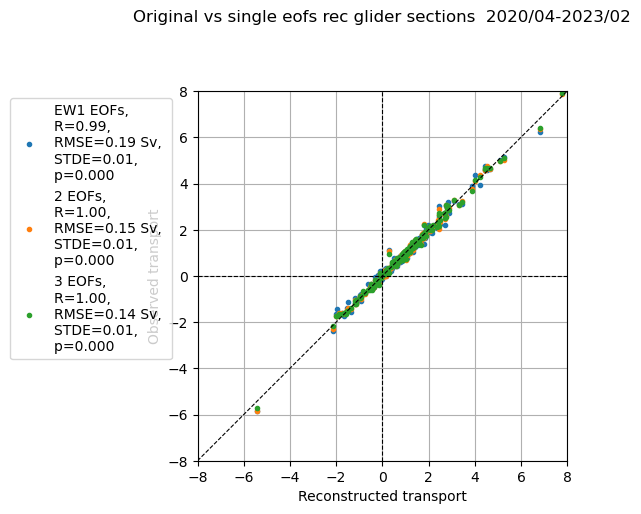

In [24]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q,
                  ds_glider.Q_rec_EOF_2,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Original vs single eofs rec glider sections  {rtv.date_str_func(ds_glider,dim='time')}', pad=50)
# plt.savefig(fig_out_path/"eofs_Q_rec_using_eofs_vs_observed.jpg")

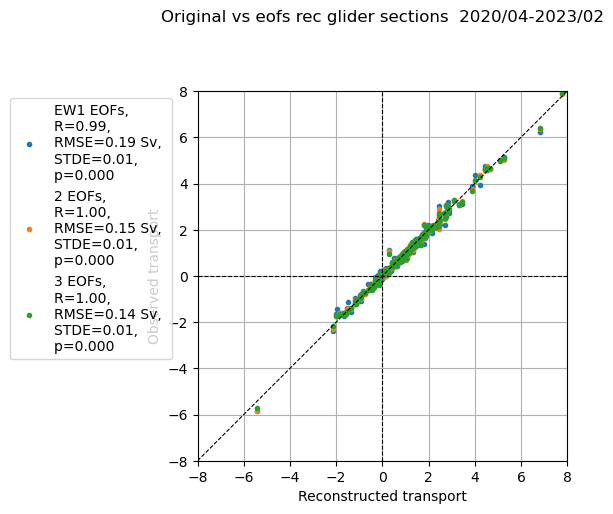

In [25]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q,
                  ds_glider.Q_rec_EOF_2,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Original vs eofs rec glider sections  {rtv.date_str_func(ds_glider,dim='time')}', pad=50)
plt.savefig(fig_out_path/"eofs_Q_rec_using_eofs_vs_observed.jpg")

Text(0.5, 1.0, 'Original vs xeofs rec glider sections  2020/04-2023/02')

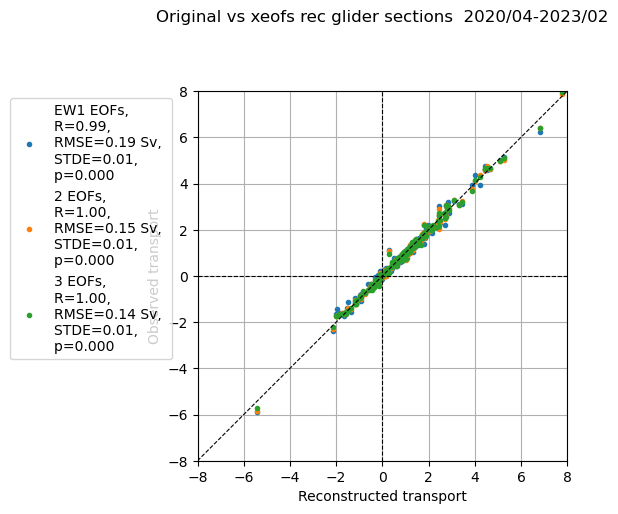

In [26]:
fig,axs = plt.subplots(1,1)
rt_eof.plot_error(ds_glider.Q,
                  ds_glider.Q_rec_EOF,
                  3,axs,var_str='Q',t_dim='time')
plt.title(f'Original vs xeofs rec glider sections  {rtv.date_str_func(ds_glider,dim='time')}', pad=50)

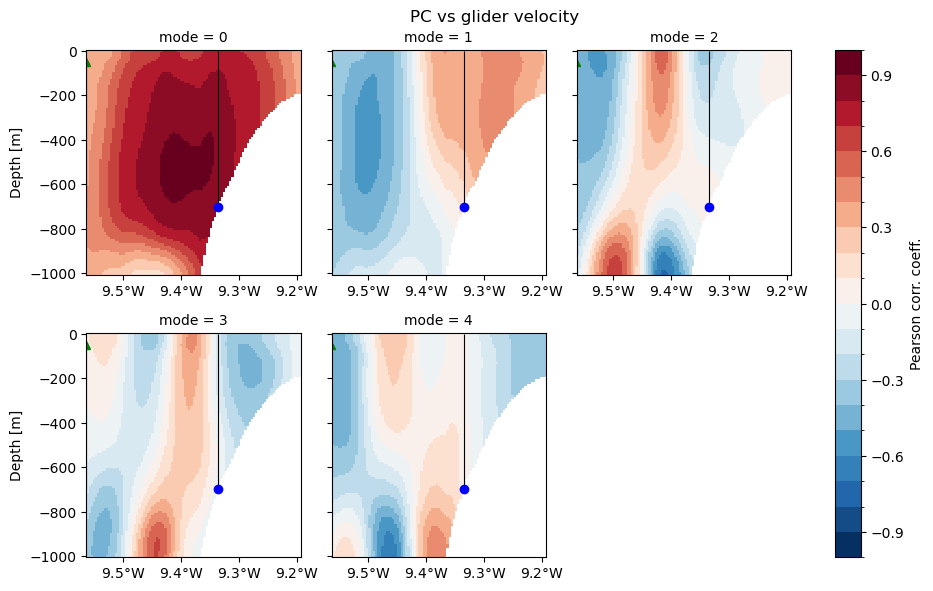

In [27]:
correlation_coeffs = xr.corr(pc1, test_vcur, dim="time")

kwargs = {"cmap": "RdBu_r", "vmin": -1, "vmax": 1,"levels":21,"cbar_kwargs": {"label": "Pearson corr. coeff."}}
g = correlation_coeffs.plot(x='lon',col='mode', col_wrap=3, sharex=False,**kwargs)
for ax in g.axes.flat:
    rtv.axis_lat_lon_formatter(ax,'xlon')
    ax.vlines(ds_RT_loc.lon_RTADCP,-700,0,color='k',lw=.8)
    ax.plot(ds_RT_loc.lon_RTADCP,-700,'ob')
    
    ax.vlines(ds_RT_loc.lon_RTEB,-700,-50,color='k',lw=.8)
    ax.plot(ds_RT_loc.lon_RTEB,-50,'^g')

g.fig.suptitle('PC vs glider velocity',y=1.01)

plt.savefig(fig_out_path/"R_pc_vs_glider.jpg")

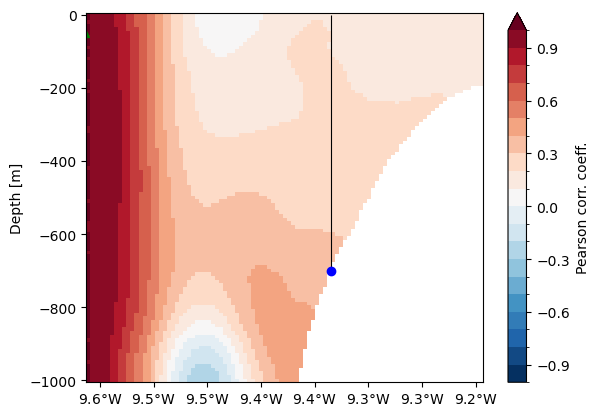

In [28]:
correlation_coeffs = xr.corr(test_vcur.sel(lon=ds_RT_loc.lon_RTEB,method='nearest'),
                             test_vcur,
                             dim="time")
g = correlation_coeffs.plot(x='lon',**kwargs)
ax=g.axes
rtv.axis_lat_lon_formatter(ax,'xlon')
ax.vlines(ds_RT_loc.lon_RTADCP,-700,0,color='k',lw=.8)
ax.plot(ds_RT_loc.lon_RTADCP,-700,'ob')

ax.vlines(ds_RT_loc.lon_RTEB,-700,-50,color='k',lw=.8)
ax.plot(ds_RT_loc.lon_RTEB,-50,'^g')

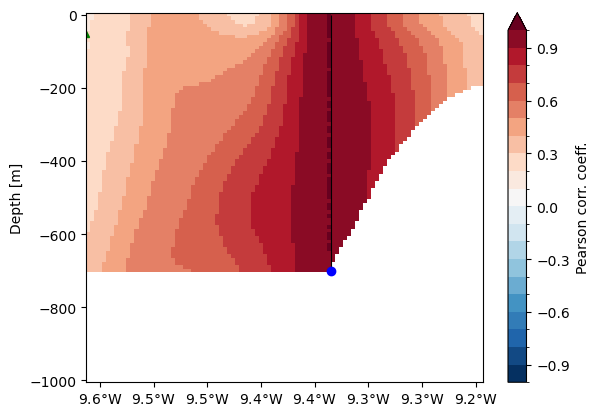

In [29]:
correlation_coeffs = xr.corr(test_vcur.sel(lon=ds_RT_loc.lon_RTADCP,method='nearest'),
                             test_vcur,
                             dim="time")
g = correlation_coeffs.plot(x='lon',**kwargs)
ax=g.axes
rtv.axis_lat_lon_formatter(ax,'xlon')
ax.vlines(ds_RT_loc.lon_RTADCP,-700,0,color='k',lw=.8)
ax.plot(ds_RT_loc.lon_RTADCP,-700,'ob')

ax.vlines(ds_RT_loc.lon_RTEB,-700,-50,color='k',lw=.8)
ax.plot(ds_RT_loc.lon_RTEB,-50,'^g')

In [30]:
time_diff = ds_glider.time.diff('time')

# 3. Define one day as a numpy.timedelta64 object
one_day = np.timedelta64(1, 'D')

# 4. Divide the time difference by one day to get the result in days
time_diff_days = time_diff / one_day

# Optional: Convert the numeric array to a list of formatted strings
# for easy human-readable output
formatted_diffs = [f"{t:.1f} days" for t in time_diff_days.values]

# print("Original Time Difference (timedelta64):\n", time_diff)
# print("\nTime Difference in Days (numeric):\n", time_diff_days)
# print("\nTime Difference in Days (human-readable string format):\n", formatted_diffs)
median_value = time_diff_days.median().values
print(f'Median time difference: {median_value:.2f}')

min_value = time_diff_days.min().values
max_value = time_diff_days.max().values
print(f'Min time difference: {min_value:.2f}')
print(f'Max time difference: {max_value:.2f}')

Median time difference: 2.88
Min time difference: 0.96
Max time difference: 159.72


In [31]:
time_diff = ds_RT.TIME.diff('TIME')

# 3. Define one day as a numpy.timedelta64 object
one_day = np.timedelta64(1, 'D')

# 4. Divide the time difference by one day to get the result in days
time_diff_days = time_diff / one_day

# Optional: Convert the numeric array to a list of formatted strings
# for easy human-readable output
formatted_diffs = [f"{t:.1f} days" for t in time_diff_days.values]

# print("Original Time Difference (timedelta64):\n", time_diff)
# print("\nTime Difference in Days (numeric):\n", time_diff_days)
# print("\nTime Difference in Days (human-readable string format):\n", formatted_diffs)
time_diff_days.median()

<xarray.DataArray 'TIME' ()> Size: 8B
array(0.5)
Attributes: (8)

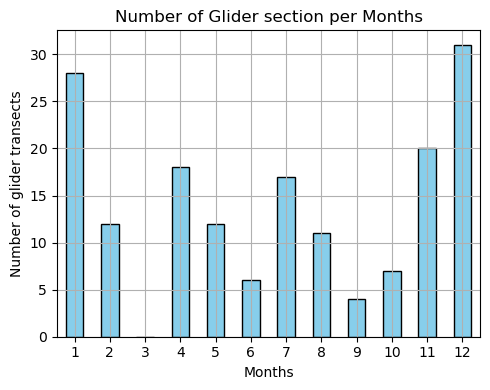

In [32]:
# 1. Extract the day of year
test_vcur["month"] = test_vcur["time"].dt.month
glider_period_str = rtv.date_str_func(ds_glider,dim='time',formatter="%Y",save_pic=True)

# 2. Group by day of year and 3. Count observations
# Count non-null observations for 'variable'
monthly_counts = test_vcur.month.groupby('month').count()

# 3. Create a complete list of months (1-12) and reindex
all_months = xr.DataArray(
    np.arange(1, 13),
    coords={'month': np.arange(1, 13)},
    dims=['month']
)
full_monthly_counts = monthly_counts.reindex_like(all_months, fill_value=0)

# # 4. Plot the results
fig = plt.figure(figsize=(5,4))
full_monthly_counts.to_series().plot.bar(
    color='skyblue',
    edgecolor='black',
    rot=0
)
plt.title('Number of Glider section per Months')
plt.xlabel('Months')
plt.ylabel('Number of glider transects')
plt.grid(True)
plt.tight_layout()
plt.show()
fig.savefig(fig_out_path/f"No_glider_sections_per_months_{glider_period_str}.jpg")

In [33]:
# def resample_to_glider_data(v_RTEB1,ds_glider,t_dim='TIME')
#     # Aerage regular mooring dataset onto the irregular time steps of glider dataset
#     # using a window of ±1 day
#     v_RTEB1=(ds_RT.V_EAST/1e2).rename({t_dim:'time'})
    
#     # 2. Define the averaging window (±1 day)
#     window_size = pd.Timedelta(days=1)
    
#     # 3. Create an empty list to hold the averaged results
#     averaged_values = []
    
#     # 4. Loop through each irregular time step
#     for t_irreg in ds_glider.time.values:
#         # Define the time window for the regular data
#         start_time = t_irreg - window_size
#         end_time = t_irreg + window_size
    
#         # Select the regular data within the window
#         # .sel(time=slice(start_time, end_time)) is the key step
#         data_in_window = v_RTEB1.sel(time=slice(start_time, end_time))
        
#         # Check if there is any data in the window to avoid issues with empty selections
#         if data_in_window.size > 0:
#             # Average the data in the window
#             average_value = data_in_window.mean(dim='time')
#             averaged_values.append(average_value.values)
#         else:
#             # Append NaN if no data is found for a given time window
#             averaged_values.append(np.nan)
    
#     # 5. Create a new xarray DataArray with the averaged values
#     v_RTEB1_resampled = xr.DataArray(
#         averaged_values,
#         coords={'time': ds_glider.time,
#                'depth': v_RTEB1.depth*-1,
#                'PRES': v_RTEB1.PRES},
#         dims=['time','depth']
#     )
    # return v_RTEB1_resampled

v_RTEB1=(ds_RT.V_EAST/1e2)
v_RTEB1_resampled = rt_eof.resample_to_glider_data(v_RTEB1,ds_glider,t_dim='TIME')

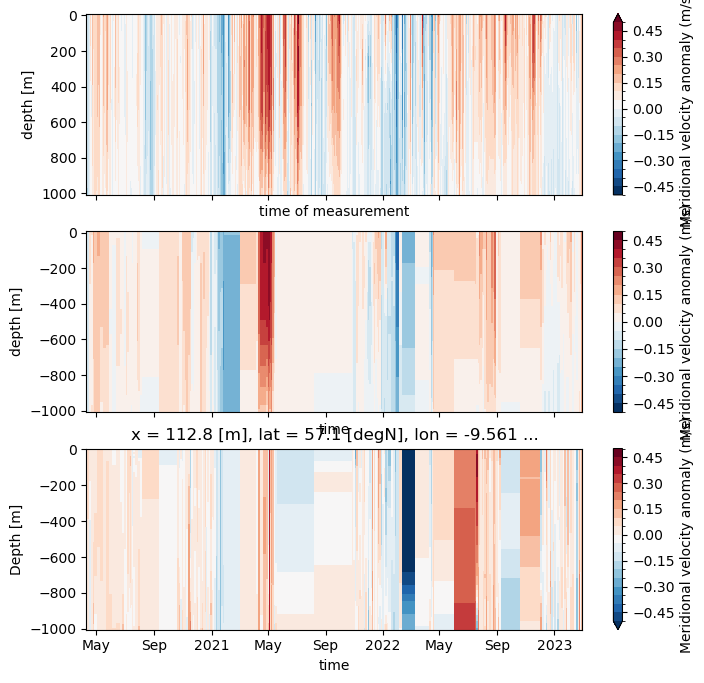

In [34]:
kwargs = {"cmap": "RdBu_r", "vmin": -.5, "vmax": .5,"levels":21,
          "cbar_kwargs": {"label": "Meridional velocity anomaly (m/s)"}}
fig,axs = plt.subplots(3,1,sharex=True,figsize=(8,8))
ax = axs[0]
(v_RTEB1).sel(depth=slice(None,1000)).plot(ax=ax, x='TIME',**kwargs,yincrease=False)
ax = axs[1]
(v_RTEB1_resampled).sel(depth=slice(None,-1000)).plot(ax=ax, x='time',**kwargs)
ax = axs[2]
(ds_glider.vcur).sel(lon=ds_RT_loc.lon_RTEB,method='nearest'
                         ).plot(ax=ax, x='time',**kwargs)

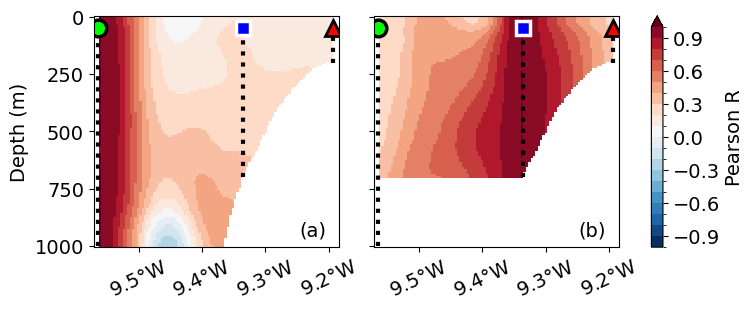

In [60]:
v_EB1_A = (v_RTEB1_resampled-v_RTEB1_resampled.mean('time')).interp(depth=test_vcur.depth)
kwargs = {"cmap": "RdBu_r", "vmin": -1, "vmax": 1,"levels":21,
          "cbar_kwargs": {"label": "Pearson R"}}
correlation_coeffs1 = xr.corr(v_EB1_A,
                             test_vcur,
                             dim="time")
correlation_coeffs2 = xr.corr(test_vcur.sel(lon=ds_RT_loc.lon_RTEB,method='nearest'),
                             test_vcur,
                             dim="time")
correlation_coeffs3 = xr.corr(test_vcur.sel(lon=ds_RT_loc.lon_RTADCP,method='nearest'),
                             test_vcur,
                             dim="time")
combined_da = xr.concat([correlation_coeffs1,correlation_coeffs2,correlation_coeffs3], 
                        dim=pd.Index([
                            'Mooring (EB1) vs. Glider',
                            'Glider (at EB1) vs. Glider',
                            'Glider (at RTADCP) vs. Glider'], name='Correlation'))
combined_da['depth'] = abs(combined_da.depth)

min_lon = combined_da.lon.min().values-0.01
max_lon = combined_da.lon.max().values+0.01

fs = 14
font = {'weight' : 'normal',
    'size'   : fs}
plt.rc('font', **font)

g = combined_da.isel(Correlation=[1,2]).plot(
    x='lon',
    col='Correlation',
    col_wrap=2,
    sharex=False,
    figsize=[8,3.5],
    yincrease=False,
    **kwargs
)
import string
g.axes[0,0].set_ylabel('Depth (m)')
for i,ax in enumerate(g.axes.flat):
    ax.set_title('')
    ax.text(0.95, 0.05, f'({string.ascii_lowercase[i]})',
            transform=ax.transAxes,ha='right' )
    rtv.axis_lat_lon_formatter(ax,'xlon')
    
    ax.tick_params(axis='x', labelrotation=25)
    ax.vlines(ds_RT_loc.lon_RTADCP,700,50,color='k',ls=':',lw=3)
    ax.plot(ds_RT_loc.lon_RTADCP,50, marker='s', 
            markerfacecolor='b', 
            markeredgecolor='w',     # White border
            markersize=10, 
            mew=2.5)
    
    ax.vlines(ds_RT_loc.lon_RTEB,1000,50,color='k',ls=':',lw=3)
    ax.plot(ds_RT_loc.lon_RTEB,50,marker='o', 
            markerfacecolor='lime', 
            markeredgecolor='k',     # White border
            markersize=12,
            mew=2.5)
    
    ax.vlines(ds_RT_loc.lon_RTES,200,50,color='k',ls=':',lw=3)
    ax.plot(ds_RT_loc.lon_RTES,50,marker='^', 
            markerfacecolor='r', 
            markeredgecolor='k',     # White border
            markersize=12,
            mew=2)

    
    ax.set_xlim([min_lon,max_lon])

fig_out_path_od = Path("C:/Users/sa07kb/OneDrive - SAMS/RT_tansports_2014_2022/figures/")
for path_str in {fig_out_path,fig_out_path_od}:
    plt.savefig(path_str/"R_location_vs_glider.png",dpi=300,bbox_inches='tight')

In [ ]:
correlation_coeffs = xr.corr(pc1, v_EB1_A, dim="time")
g= correlation_coeffs.plot(x='mode',**kwargs)
g.axes.set_title('PC vs mooring EB1 velocities')
plt.savefig(fig_out_path/"R_pc_vs_EB1.jpg")

# Animation

In [ ]:
ds_glider

In [ ]:
# from matplotlib.animation import ImageMagickWriter
# ds_glider_nan = rt_eof.add_nan_glider_sections(ds_glider,dim='time')
# kwargs = {"cmap": "RdBu_r", "vmin": -.5, "vmax": .5,
#           "levels":21,"cbar_kwargs": {"label": "Meridional Velocity (m/s)"}}

# # Turn off the interactive plotting for video generation
# plt.ioff()

# # --- 2. Set up the figure and subplots ---
# fig = plt.figure(figsize=(8,8))
# fig.suptitle('Glider section and transport')
# gs = GridSpec(2, 1, width_ratios=[1], height_ratios=[2, 1])
# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])

# # --- 3. Initialize the plots ---
# contour_plot = ds_glider.vcur.isel(time=0).plot.contourf(ax=ax1,x='lon',**kwargs)

# time_step=ds_glider.time.isel(time=0).dt.strftime('%Y/%m/%d').values
# ax1.set_title(f'Glider Data at Time Step {time_step}')
# rtv.axis_lat_lon_formatter(ax1,'xlon')
# ax1.vlines(ds_RT_loc.lon_RTADCP,-700,0,color='k',lw=.8)
# ax1.plot(ds_RT_loc.lon_RTADCP,-700,'ob')
# ax1.vlines(ds_RT_loc.lon_RTEB,-700,-50,color='k',lw=.8)
# ax1.plot(ds_RT_loc.lon_RTEB,-50,'^g')

# ds_glider_nan.Q.plot.line('-',ax=ax2,label='glider',color='C0')
# ax2.set_xlabel('');

# marker, = ax2.plot(ds_glider.time.values[0], ds_glider.Q.values[0],
#                    marker='o', color='red', markersize=5, label='Current Time Step')
# ax2.legend() #loc='upper right', bbox_to_anchor=(1.0, 1.2))
# ax2.grid()
# plt.tight_layout()

# def update(frame):
#     # Clear old contour plot collections
#     ax1.clear()
#     # Redraw a new contour plot for the current frame's data
#     current_v = ds_glider['vcur'].isel(time=frame).transpose('depth','lon').values
#     new_contour_plot = ax1.contourf(
#         ds_glider['lon'], ds_glider['depth'], current_v, **kwargs
#     )

#     rtv.axis_lat_lon_formatter(ax1,'xlon')
#     ax1.vlines(ds_RT_loc.lon_RTADCP,-700,0,color='k',lw=.8)
#     ax1.plot(ds_RT_loc.lon_RTADCP,-700,'ob')
#     ax1.vlines(ds_RT_loc.lon_RTEB,-700,-50,color='k',lw=.8)
#     ax1.plot(ds_RT_loc.lon_RTEB,-50,'^g')
    
#     # Select the data for the current frame
#     current_time = ds_glider['time'].values[frame]
#     current_Q = ds_glider.Q.values[frame]

#     # Update the marker's position using the `set_data` method
#     marker.set_data([current_time], [current_Q])

#     # Update title
#     time_step=ds_glider.time.isel(time=frame).dt.strftime('%Y/%m/%d').values
#     ax1.set_title(f'Glider Data at Time Step {time_step}')

#     # Return the artist object(s) to be redrawn
#     return marker,


# # Use FuncAnimation to create the animation
# num_frames = len(ds_glider['time'])
# ani = FuncAnimation(
#     fig,
#     update,
#     frames=num_frames,
#     interval=200,  # Milliseconds between frames
#     blit=True     # Use blitting for performance
# )

# # python
# # To save the animation as a GIF
# ani.save(fig_out_path/'timeseries_marker_animation.gif', writer='pillow', fps=1)
# ani.save(fig_out_path/'timeseries_marker_animation.mp4', writer='ffmpeg', fps=10)
# # Convert to HTML5 video with a lower FPS for slower playback
# video = ani.to_html5_video()
# # Display the video player in the notebook
# HTML(video)
# # Close the figure
# plt.close(fig)

In [ ]:
# writer = ImageMagickWriter(fps=10)
# ani.save('glider_animation.mp4', writer=writer) need to in